In [ ]:
!pip install watermark pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.1 MB/s eta 0:00:00


In [ ]:
from watermark import watermark
print(watermark(current_time=True,packages="pandas,matplotlib,seaborn,pingouin"))

pandas    : 2.2.2
matplotlib: 3.10.0
seaborn   : 0.13.2
pingouin  : 0.5.5



In [ ]:
# This shows the default Python in Colab
!python -V

Python 3.11.11


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from pingouin import intraclass_corr, anova

# Load the CSV file
file_path1 = "./Results_1.csv"  # Replace with your file path
data1 = pd.read_csv(file_path1, sep=';')

file_path2 = "./Results_2.csv"  # Replace with your file path
data2 = pd.read_csv(file_path2, sep=';')

file_path3 = "./Results_3.csv"  # Replace with your file path
data3 = pd.read_csv(file_path3, sep=';')

data = pd.concat([data1, data2, data3])


In [ ]:
# Convert decimal commas to decimal points in relevant columns
for col in ['Percentage', 'Score', 'Run',]:
    data[col] = data[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
# prompt: round column Percentage

data['Percentage'] = data['Percentage'].round(2)

In [ ]:
data['Filename'] = data['Filename'].str.replace('_TIFF', '', regex=False)

In [ ]:
data

,Filename,Percentage,Score,Run
0,CT1_1,32.11,3.0,1.0
1,CT1_1,42.14,3.0,1.0
2,CT2,18.15,2.0,1.0
3,CT4,74.76,4.0,1.0
4,CT3,37.70,3.0,1.0
5,CT1_1,32.83,3.0,1.0
6,CT2,11.79,2.0,1.0
7,CT5,2.84,1.0,1.0
8,CT4,71.12,4.0,1.0
9,CT3,28.11,3.0,1.0


In [ ]:
# Check the structure of the data
print(data.head())

# Ensure the columns are correct
required_columns = {"Filename", "Run", "Score", "Percentage"}
if not required_columns.issubset(data.columns):
    raise ValueError(f"CSV must contain the columns: {required_columns}")

# Group by Filename and compute statistics for Score and Percentage
grouped = data.groupby("Filename")

results = []
for metric in ["Score", "Percentage"]:
    # Compute standard deviation and coefficient of variation
    grouped_stats = grouped[metric].agg(["mean", "std"])
    grouped_stats["cv"] = grouped_stats["std"] / grouped_stats["mean"]  # Coefficient of variation
    grouped_stats["metric"] = metric
    results.append(grouped_stats)

# Combine results
stats_df = pd.concat(results)
print("\nStandard Deviation and CV for Each Metric:")
print(stats_df)

# Perform ANOVA for each metric
anova_results = {}
for metric in ["Score", "Percentage"]:
    anova_result = anova(dv=metric, between="Filename", data=data)
    anova_results[metric] = anova_result
    print(f"\nANOVA Results for {metric}:")
    print(anova_result)

# Compute ICC for each metric
icc_results = {}
for metric in ["Score", "Percentage"]:
    icc_result = intraclass_corr(
        data=data,
        targets="Filename",
        raters="Run",
        ratings=metric,
        nan_policy='omit'  # This will automatically handle missing values
    )
    icc_results[metric] = icc_result
    print(f"\nICC Results for {metric}:")
    print(icc_result)

# Save results to CSV files
stats_df.to_csv("./intra_variance_stats.csv", index=True)
for metric, result in icc_results.items():
    result.to_csv(f"./icc_results_{metric}.csv", index=False)
for metric, result in anova_results.items():
    result.to_csv(f"./anova_results_{metric}.csv", index=False)

print("\nAnalysis completed. Results saved to CSV files.")


  Filename  Percentage  Score  Run
0    CT1_1       32.11    3.0  1.0
1    CT1_1       42.14    3.0  1.0
2      CT2       18.15    2.0  1.0
3      CT4       74.76    4.0  1.0
4      CT3       37.70    3.0  1.0

Standard Deviation and CV for Each Metric:
               mean        std        cv      metric
Filename                                            
CT1_1      2.888889   0.333333  0.115385       Score
CT1_2      3.000000   0.707107  0.235702       Score
CT2        1.777778   0.440959  0.248039       Score
CT3        3.000000   0.000000  0.000000       Score
CT4        4.000000   0.000000  0.000000       Score
CT5        1.000000   0.000000  0.000000       Score
CT1_1     39.438889   9.497811  0.240823  Percentage
CT1_2     44.026667  13.278828  0.301609  Percentage
CT2       13.830000   6.287444  0.454624  Percentage
CT3       35.173333   5.381494  0.152999  Percentage
CT4       69.836667   3.215369  0.046041  Percentage
CT5        1.448889   1.029629  0.710634  Percentage

ANO

In [ ]:
# prompt: save plot to as png

# Assuming 'stats_df' is the DataFrame you want to plot
plt.figure(figsize=(10, 6))
sns.barplot(x="metric", y="cv", data=stats_df.reset_index(), hue="Filename")
plt.title("Coefficient of Variation (CV) by Metric and Filename")
plt.xlabel("Metric")
plt.ylabel("CV")
plt.savefig("./cv_plot.png")
plt.show()

<ipython-input-17-8e06c2f632af>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Score", y="Filename", data=data,


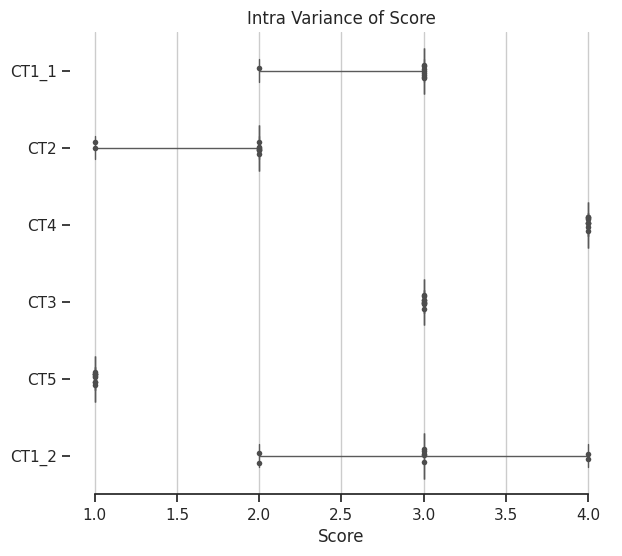

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(x="Score", y="Filename", data=data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="Score", y="Filename", data=data,
              size=4, color=".3", linewidth=0)

ax.set(
    xlabel="Score",
    ylabel="Dataset",
    title="Intra Variance of Score"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)
plt.savefig("./intra-var-score_plot.png")
plt.show()

<ipython-input-18-fb45d450870a>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Percentage", y="Filename", data=data,


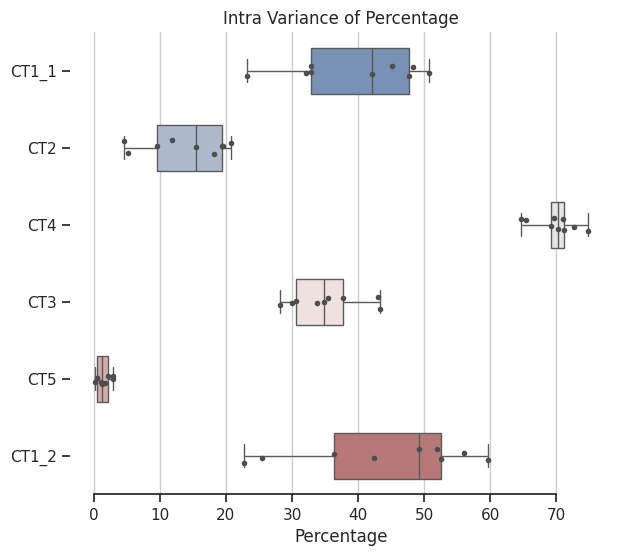

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(x="Percentage", y="Filename", data=data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="Percentage", y="Filename", data=data,
              size=4, color=".3", linewidth=0)

ax.set(
    xlabel="Percentage",
    ylabel="Dataset",
    title="Intra Variance of Percentage"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)
plt.savefig("./intra-var-percentage_plot.png")
plt.show()